<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [15]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import seaborn as sns
import scanpy as sc
# from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils as cm_utils
# importlib.reload(cm_utils)
# from cellmender.utils import plot_matrix_scatterplot

# Compare CellBender vs. cellmender

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0

In [16]:
dataset_name = "pbmc8k"  # options: tiny_cellbender, pbmc8k, simulation1, custom
rerun_alternate_tools = False  # if True, requires docker
cellbender_model = "full"  # options: ambient, swapping, full
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False
# cellbender_env = "/home/jrich/miniconda3/envs/cellbender"
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False
threads = 16

# only required if dataset_name == "custom"; if using a dataset option above, then this will override the defaults filled out below
adata_path_raw_custom = None
adata_path_cellmender_custom = None
adata_path_cellbender_custom = None
soupx_out_prefix_custom = None
decontx_out_prefix_custom = None
adata_path_scar_custom = None
sequencing_technology_custom = None
model_pkl_custom = None
matrix_tar_files_dir_custom = None
raw_tar_file_dir_custom = None
filtered_tar_file_dir_custom = None
cellmender_max_iter_custom = None
cellmender_beta_custom = None
cellmender_cell_ambient_fraction_custom = None
cellbender_epochs_custom = None
cellbender_fpr_custom = None
scar_epochs_custom = None
cellbender_total_droplets_custom = None
expected_cells_custom = None
cs_empty_threshold_custom = None
min_genes_custom = None
min_cells_custom = None
umi_top_percentile_to_remove_custom = None
unique_genes_top_percentile_to_remove_custom = None
mt_gene_percentile_to_remove_custom = None
max_mt_percentage_custom = None
n_top_genes_custom = None
n_pcs_custom = None
n_neighbors_custom = None
leiden_resolution_custom = None
marker_genes_custom = None

In [17]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

cellbender_matrix_url = None
cellbender_matrix_filtered_url = None
soupx_matrix_url = None
decontx_matrix_url = None
scar_matrix_url = None

cellmender_log_file = os.path.join(data_dir, "cellmender.log")

if dataset_name == "tiny_cellbender":
    adata_path_raw = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    adata_path_cellmender = f"{data_dir}/tiny_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    soupx_out_prefix = None  # f"{data_dir}/tiny_output_soupx"
    decontx_out_prefix = None  # f"{data_dir}/tiny_output_decontx"
    adata_path_scar = None
    sequencing_technology = "10XV2"
    model_pkl = "Adult_Mouse_Gut.pkl"  # path to celltypist model pkl file - this is a mouse heart dataset, but this is really just for debugging anyways
    
    if not os.path.exists(adata_path_raw):
        raise FileNotFoundError(f"Original matrix file not found: {adata_path_raw}. Create with CellBender's `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    matrix_tar_files_dir = None
    raw_tar_file_dir = None
    filtered_tar_file_dir = None

    cellbender_matrix_url = None
    cellbender_matrix_filtered_url = None
    soupx_matrix_url = None
    decontx_matrix_url = None
    
    cellmender_max_iter = 10
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 2
    cellbender_fpr = 0.01
    cellbender_total_droplets = 2000
    scar_epochs = 2
    expected_cells = 500
    cs_empty_threshold = 1000
    min_genes = 5
    min_cells = 3
    umi_top_percentile_to_remove = None
    unique_genes_top_percentile_to_remove = None
    mt_gene_percentile_to_remove = None
    max_mt_percentage = 50
    n_top_genes = 2000
    n_pcs = 45
    n_neighbors = 15
    leiden_resolution = 1.0
    marker_genes = {
        'Resting CD4+ T cells': ["Hbb-bs", "mt-Co3", "mt-Atp6"],
        'Paneth.progenitor': ["Eef1a1"],
        'Plasma cell': ["H3f3b"],
        'Naive B cells': ["Rpl13", "Rplp0"]
    }
elif dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    adata_path_cellmender = f"{data_dir}/pbmc8k_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    soupx_out_prefix = f"{data_dir}/pbmc8k_output_soupx"
    decontx_out_prefix = f"{data_dir}/pbmc8k_output_decontx"
    adata_path_scar = f"{data_dir}/pbmc8k_output_scar.h5ad"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir):
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir):
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

    cellbender_matrix_url = "https://caltech.box.com/shared/static/trxd26eqmr33cg3ot0l3jins9s193ob6.h5"
    cellbender_matrix_filtered_url = "https://caltech.box.com/shared/static/bnilabzuvdvtm1knpsfgy89php938qft.h5"
    soupx_matrix_url = "https://caltech.box.com/shared/static/7lhpw8bgwf3b3gyl7wgqe15h3yhxamld.gz"
    decontx_matrix_url = "https://caltech.box.com/shared/static/zzfs06lp634g2rhuuph200rvga08atzh.gz"
    scar_matrix_url = ""
    
    cellmender_max_iter = 40
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_total_droplets = 12_000
    scar_epochs = 200
    expected_cells = 9000
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 5
    unique_genes_top_percentile_to_remove = 5
    mt_gene_percentile_to_remove = 10
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 1.0
    marker_genes = {
        "Monocytes/neutrophils": ["S100A8", "S100A9", "S100A12", "FCGR3A"],
        "Monocytes/pDCs": ["LYZ", "CST3", "FCN1", "LILRA4"],
        "T": ["IL32", "TRAC", "CCR7", "FOXP3", "CD8A", "CD8B", "NKG7", "GNLY", "TRGC1", "SLC4A10"],
        "B": ["IGHD", "CD79A", "FCER2", "TNFRSF13B"],
        "NK": ["KLRF1", "SPON2"],
        "Progenitor": ["PPBP"],
        "Baso./neutro./progenitor": ["SDPR", "CLU"],
        "(Broad expression)": ["PTPRC"]
    }
# elif dataset_name == "simulation1":
#     if not os.path.exists(adata_path_raw):
#         adata = cm_utils.simulate_cells(adata_path_raw, ...)
    
#     paths = cm_utils.write_10x_like(adata, matrix_tar_files_dir)

#     # # soupx inputs
#     # matrix_tar_files_dir = matrix_tar_files_dir
#     adata_soupx_obs_csv = paths["celltypes"]
#     # soupx_out_prefix

#     # # decontx inputs
#     raw_tar_file_dir = paths["raw"]
#     filtered_tar_file_dir = paths["filtered"]
#     sequencing_technology = paths["technology"]
#     # decontx_out_prefix
#     #!!! continue filling out

# set any custom variables provided by the user
for var in ["adata_path_raw", "adata_path_cellmender", "adata_path_cellbender", "soupx_out_prefix", "decontx_out_prefix", "sequencing_technology", "model_pkl", "matrix_tar_files_dir", "raw_tar_file_dir", "filtered_tar_file_dir", "cellmender_max_iter", "cellmender_beta", "cellmender_cell_ambient_fraction", "cellbender_epochs", "cellbender_fpr", "cellbender_total_droplets", "scar_epochs", "expected_cells", "cs_empty_threshold", "min_genes", "min_cells", "umi_top_percentile_to_remove", "unique_genes_top_percentile_to_remove", "mt_gene_percentile_to_remove", "max_mt_percentage", "n_top_genes", "n_pcs", "n_neighbors", "leiden_resolution", "marker_genes"]:
    custom = globals().get(f"{var}_custom")
    if custom is not None:
        globals()[var] = custom

adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")

## Raw

In [ ]:
if adata_path_raw.endswith(".h5ad"):
    adata_raw = ad.read_h5ad(adata_path_raw)
elif adata_path_raw.endswith(".h5"):
    adata_raw = sc.read_10x_h5(adata_path_raw)
else:
    raise ValueError(f"Original matrix file must be either .h5ad or .h5 format. Found: {adata_path_raw}")
adata_raw.var_names_make_unique()

## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (9000): 298.00


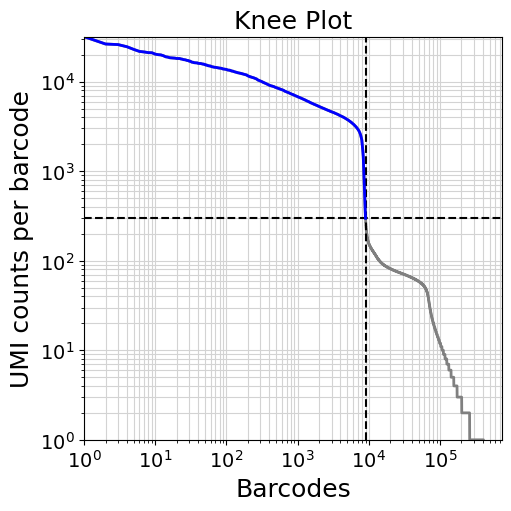

In [19]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [20]:
# umi_cutoff = 0  #!!! optionally update from knee plot

In [ ]:
import importlib
import cellmender.celltype_ambient
importlib.reload(cellmender.celltype_ambient)
from cellmender.celltype_ambient import denoise_count_matrix

_ = denoise_count_matrix(adata, adata_out="/home/jrich/Desktop/cellmender/notebooks/data/pbmc8k222/pbmc8k_output_cellmender.h5ad", max_iter=cellmender_max_iter, beta=cellmender_beta, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=cellmender_cell_ambient_fraction, verbose=verbose, log_file=cellmender_log_file)

Logging to /home/jrich/Desktop/cellmender/notebooks/data/pbmc8k/cellmender.log


09:13:05 - INFO - Added 'ambient_fraction' to adata.var.
09:13:05 - INFO - Inferring celltype profiles.
09:13:05 - INFO - Number of parameters in the cellmender model: 393,247 (alpha_i: 9,000, beta: 1, gamma_type: 81,000, p_k: 303,246)


## cellmender

In [22]:
%%time
if not os.path.exists(adata_path_cellmender) or overwrite:
    adata = adata_raw.copy()
    adata = cm_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
    _ = denoise_count_matrix(adata, adata_out=adata_path_cellmender, max_iter=cellmender_max_iter, beta=cellmender_beta, eps=1e-9, empty_droplet_method="threshold", expected_cells=expected_cells, cell_ambient_fraction=cellmender_cell_ambient_fraction, verbose=verbose, log_file=cellmender_log_file)

CPU times: user 82 μs, sys: 1 μs, total: 83 μs
Wall time: 99.2 μs


In [23]:
adata_cellmender = ad.read_h5ad(adata_path_cellmender)
adata_cellmender = adata_cellmender[~adata_cellmender.obs["is_empty"]].copy()
adata_cellmender.var_names_make_unique()
print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellmender)}")

Counts are less than or equal check for CellMender: True


## CellBender (v0.3.0)

In [24]:
%%time
if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_alternate_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          # conda_run_flag = "-p" if "/" in cellbender_env else "-n"
          # !conda run {conda_run_flag} {cellbender_env} \ 
          !docker run --rm -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               cellbender remove-background \
               --input {input_path} \
               --output {output_path} \
               --expected-cells {expected_cells} \
               --total-droplets-included {cellbender_total_droplets} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --model {cellbender_model} \
               {runtime}
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}

CPU times: user 66 μs, sys: 1 μs, total: 67 μs
Wall time: 83.9 μs


In [25]:
# adata_cellbender_with_empty_droplets = anndata_from_h5(adata_path_cellbender)
# adata_cellbender = adata_cellbender_with_empty_droplets[adata_cellbender_with_empty_droplets.obs['cell_probability'] > 0.5]
adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
adata_cellbender.var_names_make_unique()
print(f"Counts are less than or equal check for CellBender: {cm_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [26]:
%%time
if soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite):
    if rerun_alternate_tools:
        adata_soupx_obs_csv = f"{data_dir}/pbmc8k_soupx_obs.csv"
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cm_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs.to_csv(adata_soupx_obs_csv)

        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellmender_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellmender_dir, rver_docker_workspace)}
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

CPU times: user 62 μs, sys: 0 ns, total: 62 μs
Wall time: 79.2 μs


In [27]:
adata_soupx = cm_utils.read_r_matrix_into_anndata(soupx_out_prefix)
adata_soupx.var_names_make_unique()
print(f"Counts are less than or equal check for SoupX: {cm_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [28]:
%%time
if decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite):
    if rerun_alternate_tools:
        !docker run --rm \
            -w /home/ruser/work \
            -v {cellmender_dir}:{rver_docker_workspace} \
            josephrich98/cellmender_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellmender_dir, rver_docker_workspace)} \
                {sequencing_technology} \
                {decontx_out_prefix.replace(cellmender_dir, rver_docker_workspace)}
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

CPU times: user 0 ns, sys: 92 μs, total: 92 μs
Wall time: 111 μs


In [29]:
adata_decontx = cm_utils.read_r_matrix_into_anndata(decontx_out_prefix)
adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
adata_decontx.var_names_make_unique()
print(f"Counts are less than or equal check for DecontX: {cm_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [ ]:
%%time
if adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite):
     if rerun_alternate_tools:
          runtime = "--cuda" if use_cuda else ""
          !conda run {conda_run_flag} {scar_env} \
            python {cellmender_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

In [ ]:
adata_scar = None
if adata_path_scar:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for CellMender: {cm_utils.check_counts_less_equal(adata_raw, adata_scar)}")

# Analysis

In [31]:
print(f"Raw:\n{adata_raw}\n\n")
print(f"cellmender:\n{adata_cellmender}\n\n")
print(f"CellBender:\n{adata_cellbender}\n\n")
print(f"SoupX:\n{adata_soupx}\n\n")
print(f"DecontX:\n{adata_decontx}\n\n")
print(f"scAR:\n{adata_scar}\n\n")

Raw:
AnnData object with n_obs × n_vars = 737280 × 33694
    var: 'gene_ids'


cellmender:
AnnData object with n_obs × n_vars = 9000 × 33694
    obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
    var: 'gene_ids', 'ambient_fraction', 'ambient_hat'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'p_hat'
    layers: 'denoised'


CellBender:
AnnData object with n_obs × n_vars = 8752 × 33694
    var: 'gene_ids', 'feature_types', 'genome'


SoupX:
AnnData object with n_obs × n_vars = 8381 × 33694


DecontX:
AnnData object with n_obs × n_vars = 8381 × 33694


scAR:
None




## UpSet plot of retained cells

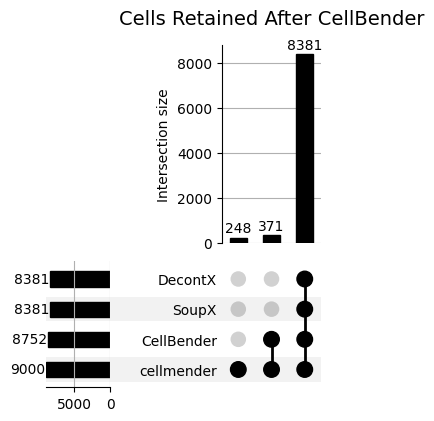

In [32]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellmender": set(adata_cellmender.obs_names),
    "CellBender": set(adata_cellbender.obs_names),
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cm_utils.make_upset_plot(upset_data_dict, title="Cells Retained After CellBender", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

In [22]:
# cm_utils.plot_difference_heatmap(adata_cellbender, adata_cellmender, cell_subset=50, gene_subset=70, show_cell_names=False, title="CellBender - cellmender Expression Differences", out_path=os.path.join(out_dir, "cellbender_vs_cellmender_heatmap.png"))

In [ ]:
# #!!! remove densification
# cm_utils.plot_matrix_scatterplot(adata_cellbender, adata_cellmender, scale="log", x_axis="cellbender", y_axis="cellmender", sample_frac=0.01, out_path=os.path.join(out_dir, "cellmender_vs_cellbender_expression_scatterplot.png"), show=True)
# if adata_soupx:
#     cm_utils.plot_matrix_scatterplot(adata_soupx, adata_cellmender, scale="log", x_axis="soupx", y_axis="cellmender", sample_frac=0.01, out_path=os.path.join(out_dir, "cellmender_vs_soupx_expression_scatterplot.png"), show=True)
# if adata_decontx:
#     cm_utils.plot_matrix_scatterplot(adata_decontx, adata_cellmender, scale="log", x_axis="decontx", y_axis="cellmender", sample_frac=0.01, out_path=os.path.join(out_dir, "cellmender_vs_decontx_expression_scatterplot.png"), show=True)
# if adata_scar:
#     cm_utils.plot_matrix_scatterplot(adata_scar, adata_cellmender, scale="log", x_axis="scar", y_axis="cellmender", sample_frac=0.01, out_path=os.path.join(out_dir, "cellmender_vs_scar_expression_scatterplot.png"), show=True)

## Histogram of per-cell Pearson correlations

In [ ]:
# !!! remove densification
# cm_utils.plot_per_cell_correlation(adata_raw, adata_cellbender, title="Per-Cell Pearson Correlation: Raw vs CellBender", out_path=os.path.join(out_dir, "raw_vs_cellbender_per_cell_correlation.png"))
# if adata_soupx:
#     cm_utils.plot_per_cell_correlation(adata_raw, adata_soupx, title="Per-Cell Pearson Correlation: Raw vs SoupX", out_path=os.path.join(out_dir, "raw_vs_soupx_per_cell_correlation.png"))
# if adata_decontx:
#     cm_utils.plot_per_cell_correlation(adata_raw, adata_decontx, title="Per-Cell Pearson Correlation: Raw vs DecontX", out_path=os.path.join(out_dir, "raw_vs_decontx_per_cell_correlation.png"))
# if adata_scar:
#     cm_utils.plot_per_cell_correlation(adata_raw, adata_scar, title="Per-Cell Pearson Correlation: Raw vs scAR", out_path=os.path.join(out_dir, "raw_vs_scar_per_cell_correlation.png"))

## stop here for tiny dataset

In [25]:
# if dataset_name == "tiny_cellbender":
#     sys.exit()

## Alluvial plot of cluster differences

In [33]:
import importlib
import cellmender.utils as cm_utils
importlib.reload(cm_utils)
from cellmender.utils import run_scanpy_preprocessing_and_clustering, determine_cell_types

adata_cellmender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellmender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellmender = cm_utils.determine_cell_types(adata_cellmender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

adata_cellbender = cm_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellbender = cm_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_soupx:
    adata_soupx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_soupx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx = cm_utils.determine_cell_types(adata_soupx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_decontx:
    adata_decontx = cm_utils.run_scanpy_preprocessing_and_clustering(adata_decontx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_decontx = cm_utils.determine_cell_types(adata_decontx, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

if adata_scar:
    adata_scar = cm_utils.run_scanpy_preprocessing_and_clustering(adata_scar, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_scar = cm_utils.determine_cell_types(adata_scar, method="celltypist", model_pkl=model_pkl, filter_empty=False, verbose=verbose)

08:55:47 - INFO - Adata initial shape: (9000, 33694)
08:55:47 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
08:55:47 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
08:55:47 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clu

In [37]:
col_names = ["cellbender", "cellmender", "soupx", "decontx", "scAR"]

# wrap in try-except block to catch errors due to wompwomp installation issues
try:
    wompwomp_leiden_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=os.path.join(out_dir, "alluvial_cluster.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
    wompwomp_celltype_df = cm_utils.plot_alluvial(adata_cellbender, adata_cellmender, adata_soupx, adata_decontx, adata_scar, names=col_names, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=os.path.join(out_dir, "alluvial_celltype.png"), wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env, verbose=verbose)
except Exception as e:
    print(f"Error generating alluvial plots with wompwomp: {e}")

09:05:48 - INFO - Running wompwomp for leiden
09:05:48 - DEBUG - conda run -p /home/jrich/miniconda3/envs/wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_cluster_df.csv --graphing_columns cellbender cellmender soupx decontx --coloring_algorithm left -o /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_cluster.png


[1] "Plot saved to: /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_cluster.png"



Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
3: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.

09:06:23 - INFO - Running wompwomp for celltype
09:06:23 - DEBUG - conda run -p /home/jrich/miniconda3/envs/wompwomp_env /home/jrich/Desktop/wompwomp/exec/wompwomp plot_alluvial --df /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype_df.csv --graphing_columns cellbender cellmender soupx decontx --coloring_algorithm left -o /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype.png


[1] "Plot saved to: /home/jrich/Desktop/cellmender/notebooks/output/pbmc8k/alluvial_celltype.png"



Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
3: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.



## Dot plots

In [28]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [40]:
if dataset_name == "pbmc8k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    reverse_map = {fine: broad for broad, fine_list in CellBender_Fig2_to_Immune_All_High_celltype_mapping.items() for fine in fine_list}
    adata_cellmender.obs["broad_celltype"] = adata_cellmender.obs["celltype"].map(reverse_map).fillna("Other")
    adata_cellbender.obs["broad_celltype"] = adata_cellbender.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_soupx:
        adata_soupx.obs["broad_celltype"] = adata_soupx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_decontx:
        adata_decontx.obs["broad_celltype"] = adata_decontx.obs["celltype"].map(reverse_map).fillna("Other")
    if adata_scar:
        adata_scar.obs["broad_celltype"] = adata_scar.obs["celltype"].map(reverse_map).fillna("Other")
    celltype_column_dotplot = "broad_celltype"
else:
    celltype_column_dotplot = "celltype"

CellMender Raw Data Dotplot


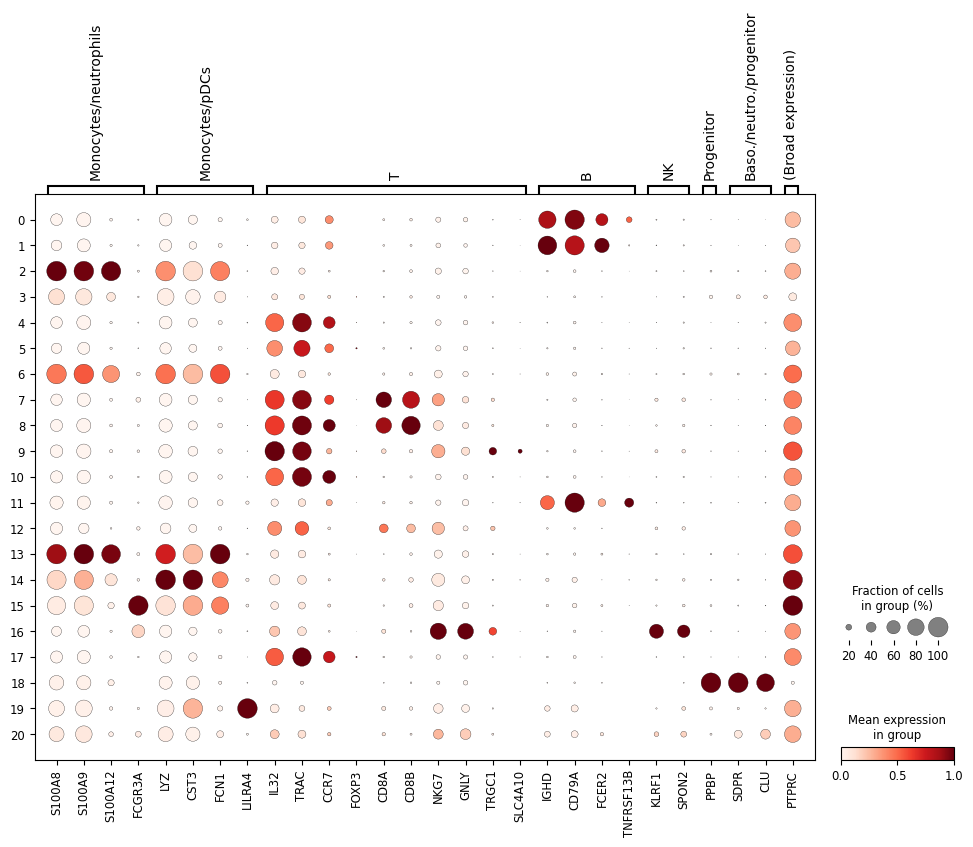

------------------------------
CellMender Processed Data Dotplot


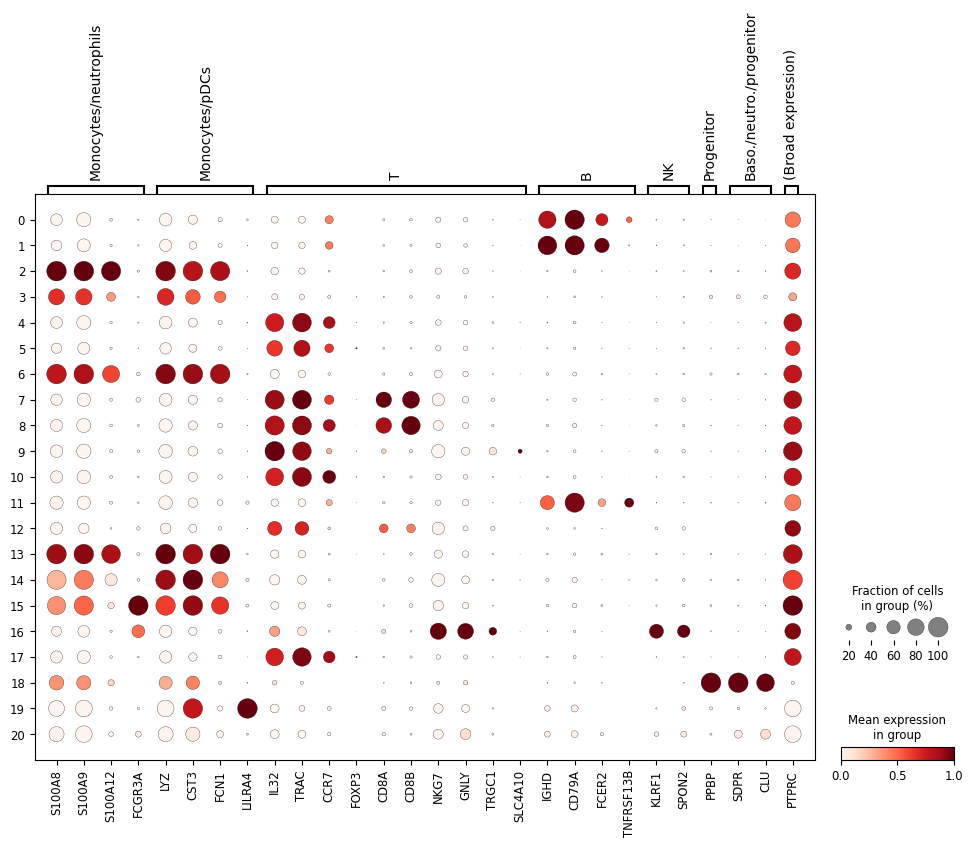

... storing 'broad_celltype' as categorical


------------------------------
CellBender Raw Data Dotplot


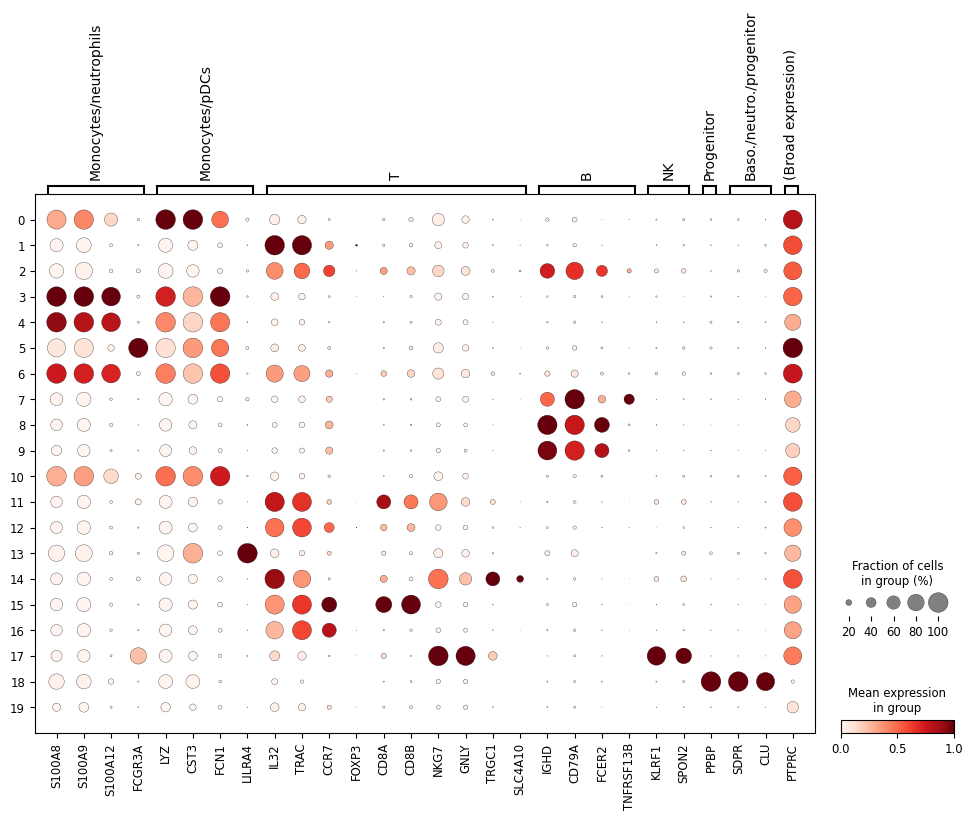

... storing 'broad_celltype' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical


------------------------------
CellBender Processed Data Dotplot


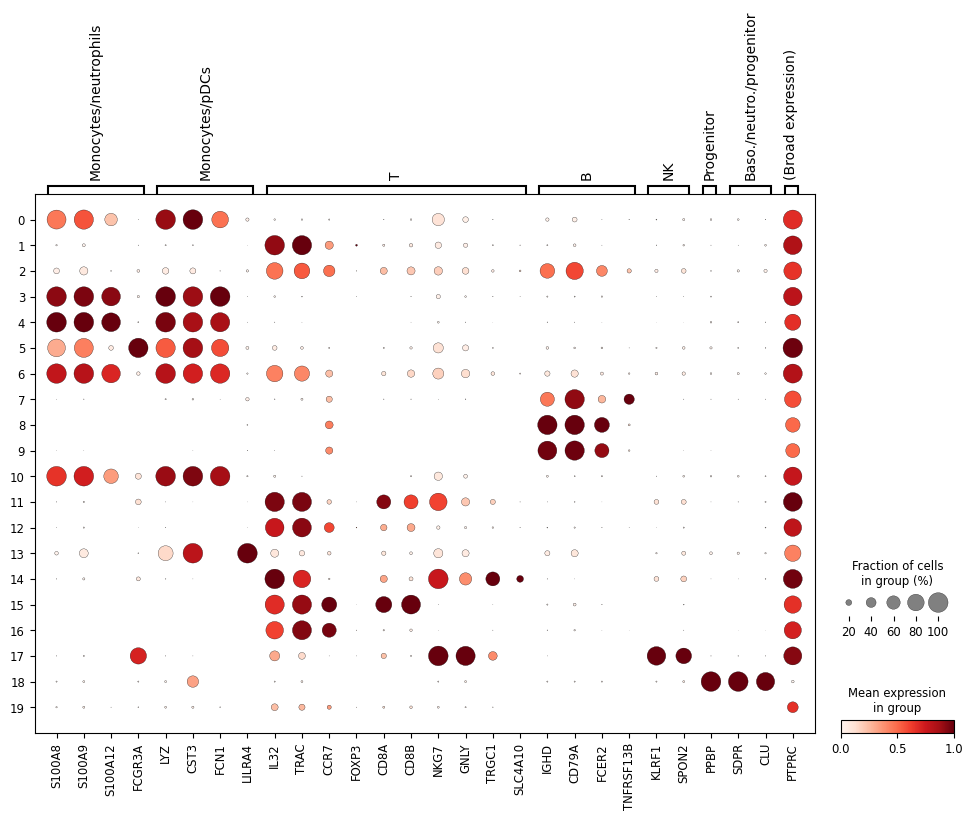

... storing 'broad_celltype' as categorical


------------------------------
SoupX Raw Data Dotplot


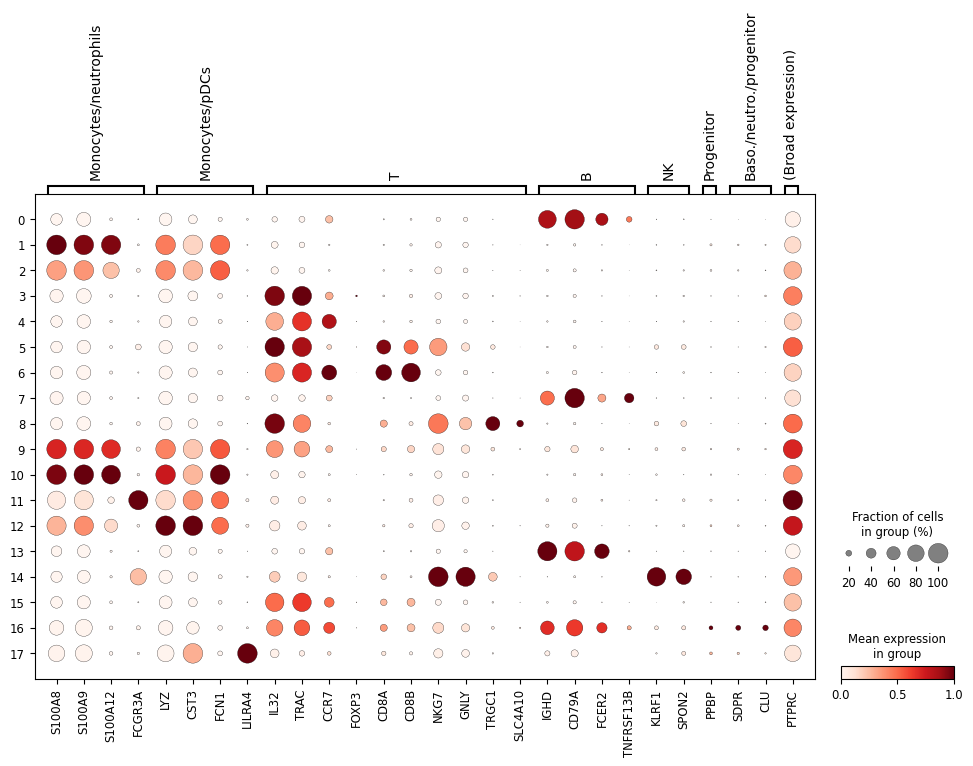

... storing 'broad_celltype' as categorical


------------------------------
SoupX Processed Data Dotplot


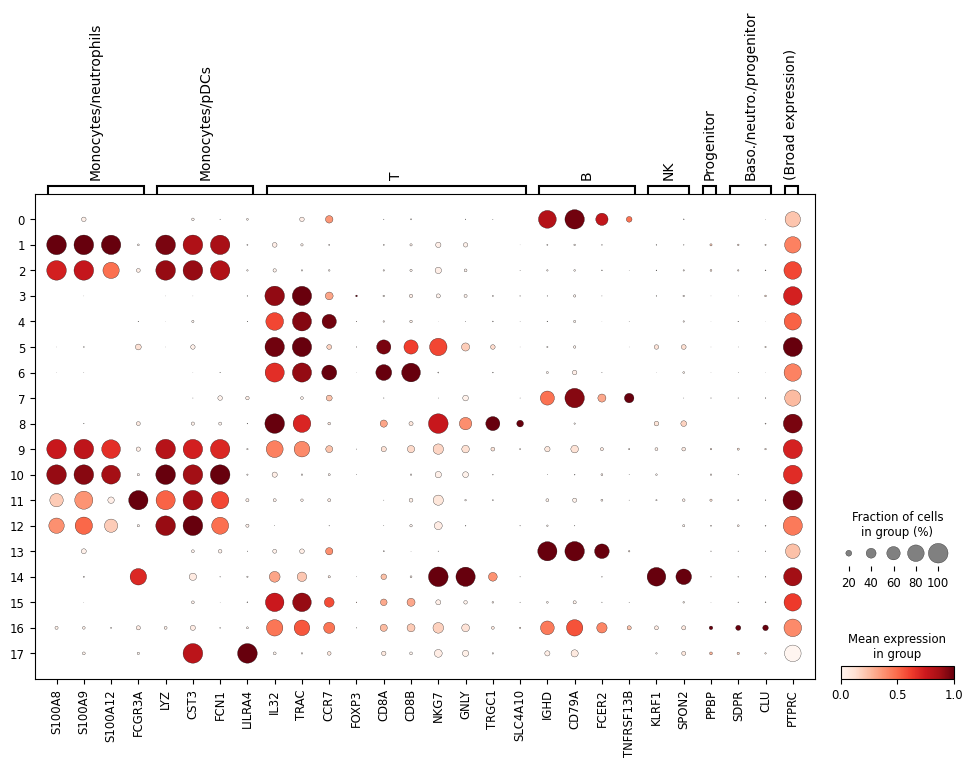

... storing 'broad_celltype' as categorical


------------------------------
DecontX Raw Data Dotplot


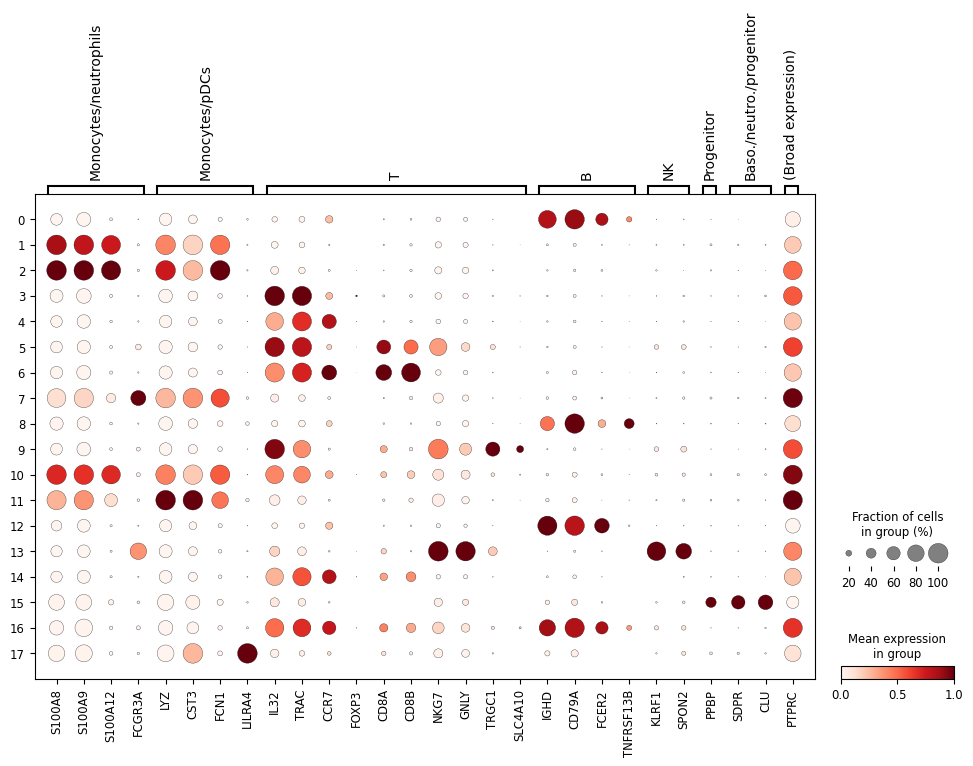

... storing 'broad_celltype' as categorical


------------------------------
DecontX Processed Data Dotplot


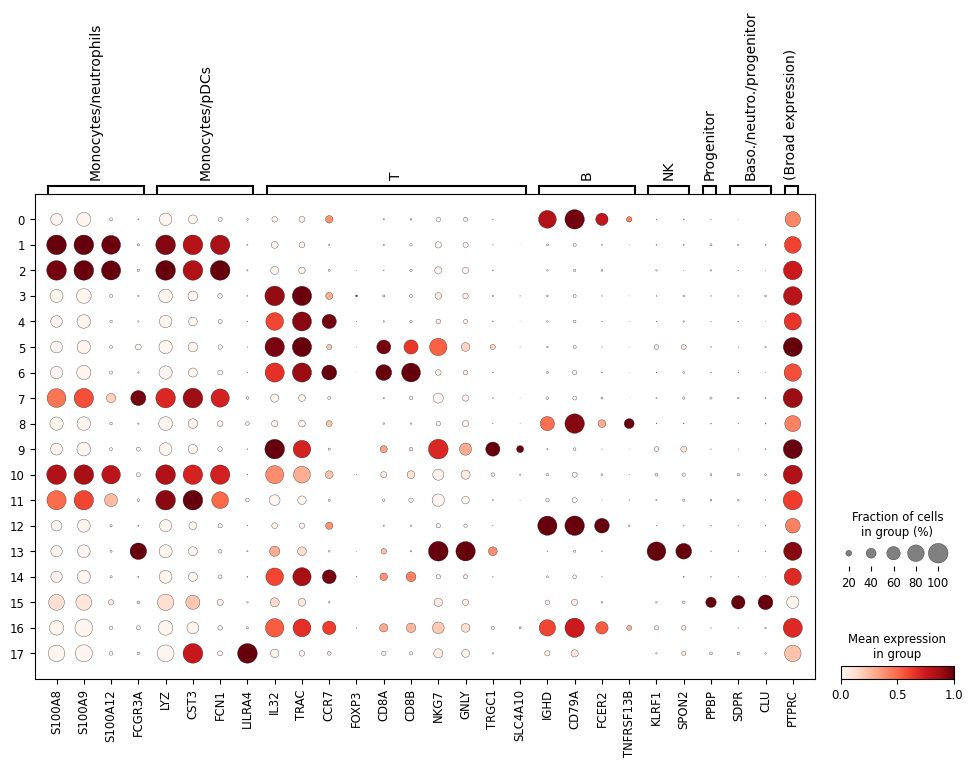

------------------------------


In [44]:
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellmender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellMender Raw Data Dotplot", title_processed="CellMender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellmender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellmender.png"))
cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_cellbender, marker_genes, celltype_column=celltype_column_dotplot, title_raw="CellBender Raw Data Dotplot", title_processed="CellBender Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_cellbender_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_cellbender.png"))
if adata_soupx:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_soupx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="SoupX Raw Data Dotplot", title_processed="SoupX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_soupx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_soupx.png"))
if adata_decontx:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_decontx, marker_genes, celltype_column=celltype_column_dotplot, title_raw="DecontX Raw Data Dotplot", title_processed="DecontX Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_decontx_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_decontx.png"))
if adata_scar:
    cm_utils.make_raw_and_processed_dotplots(adata_raw, adata_scar, marker_genes, celltype_column=celltype_column_dotplot, title_raw="scAR Raw Data Dotplot", title_processed="scAR Processed Data Dotplot", out_path_raw=os.path.join(out_dir, "dotplot_scar_raw.png"), out_path_processed=os.path.join(out_dir, "dotplot_scar.png"))

## Bonus: runtime (on our machine)

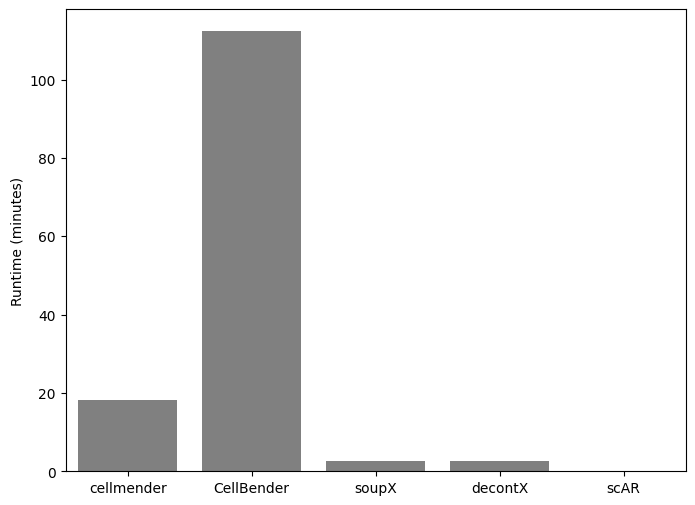

In [47]:
runtimes = {
    "cellmender": (18 + 8/60),  # 18 minutes, 8 seconds
    "CellBender": (1*60 + 52 + 20/60),  # 1 hour, 52 minutes, 20 seconds
    "soupX": (2 + 43/60),  # 2 minutes, 43 seconds
    "decontX": (2 + 37/60),  # 2 minutes, 37 seconds
    "scAR": 0
}

plt.figure(figsize=(8,6))
sns.barplot(x=list(runtimes.keys()), y=list(runtimes.values()), color="gray")
plt.ylabel("Runtime (minutes)")
plt.savefig(os.path.join(out_dir, "runtime_comparison.png"))
plt.show()

## Bonus: Number of parameters in cellmender and CellBender

In [40]:
cellmender_parameters = cm_utils.count_cellmender_parameters(cellmender_log_file)
print(cellmender_parameters)

None


In [ ]:
cellbender_parameters = cm_utils.count_cellbender_parameters("ckpt.tar.gz")
print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")


=== Model Architecture (inferred from state_dict) ===
Total parameters: 843,293

encoder_z$$$network.0.layer.0.weight               | Shape: torch.Size([512, 100]) | Params: 51,200
encoder_z$$$network.0.layer.0.bias                 | Shape: torch.Size([512])    | Params: 512
encoder_z$$$loc_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$loc_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_z$$$sig_out.weight                         | Shape: torch.Size([64, 512]) | Params: 32,768
encoder_z$$$sig_out.bias                           | Shape: torch.Size([64])     | Params: 64
encoder_other$$$layer1.weight                      | Shape: torch.Size([512, 104]) | Params: 53,248
encoder_other$$$layer1.bias                        | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.weight                  | Shape: torch.Size([512])    | Params: 512
encoder_other$$$batchnorm1.bias                